# Insurance Claim Fraud Detection Using Machine Learning

**Objective:**  
To build a machine learning classification model that predicts whether an insurance claim is fraudulent or genuine based on policy, incident, and claim-related features.

**Problem Type:** Binary Classification

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading

The insurance claims dataset is loaded into a Pandas DataFrame for analysis and machine learning.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving classification_data.xlsx to classification_data.xlsx


In [ ]:
import pandas as pd

# Read the uploaded Excel file
df = pd.read_excel("classification_data.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 39)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


## 2. Data Cleaning & Preprocessing

The dataset is first inspected to understand its structure, data types, missing values and duplicate records.

In [ ]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (1000, 39)

Data Types:
months_as_customer                      int64
age                                     int64
policy_number                           int64
policy_bind_date               datetime64[ns]
policy_state                           object
policy_csl                             object
policy_deductable                       int64
policy_annual_premium                 float64
umbrella_limit                          int64
insured_zip                             int64
insured_sex                            object
insured_education_level                object
insured_occupation                     object
insured_hobbies                        object
insured_relationship                   object
capital-gains                           int64
capital-loss                            int64
incident_date                  datetime64[ns]
incident_type                          object
collision_type                         object
incident_severity                      ob

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,NaN,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,NaN,0,0,NaN,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,NaN,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,NaN,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
months_as_customer,1000.0,203.954,0.0,115.75,199.5,276.25,479.0,115.113174
age,1000.0,38.948,19.0,32.0,38.0,44.0,64.0,9.140287
policy_number,1000.0,546238.648,100804.0,335980.25,533135.0,759099.75,999435.0,257063.005276
policy_bind_date,1000,2002-02-08 04:40:47.999999872,1990-01-08 00:00:00,1995-09-19 00:00:00,2002-04-01 12:00:00,2008-04-21 12:00:00,2015-02-22 00:00:00,NaN
policy_deductable,1000.0,1136.0,500.0,500.0,1000.0,2000.0,2000.0,611.864673
policy_annual_premium,1000.0,1256.40615,433.33,1089.6075,1257.2,1415.695,2047.59,244.167395
umbrella_limit,1000.0,1101000.0,-1000000.0,0.0,0.0,0.0,10000000.0,2297406.598118
insured_zip,1000.0,501214.488,430104.0,448404.5,466445.5,603251.0,620962.0,71701.610941
capital-gains,1000.0,25126.1,0.0,0.0,0.0,51025.0,100500.0,27872.187708
capital-loss,1000.0,-26793.7,-111100.0,-51500.0,-23250.0,0.0,0.0,28104.096686


In [ ]:
# Convert '?' into NaN
df = df.replace("?", np.nan)

# Check missing values
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
collision_type             178
authorities_contacted       91
property_damage            360
police_report_available    343
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (1000, 39)


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

Categorical columns:
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


In [ ]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### Outlier Identification

Potential outliers in numerical variables are identified using the Interquartile Range (IQR) method.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

In [ ]:
# Exclude identifier-like columns from outlier analysis
outlier_cols = [
    "months_as_customer",
    "age",
    "policy_deductable",
    "policy_annual_premium",
    "umbrella_limit",
    "capital-gains",
    "capital-loss",
    "incident_hour_of_the_day",
    "number_of_vehicles_involved",
    "bodily_injuries",
    "witnesses",
    "total_claim_amount",
    "injury_claim",
    "property_claim",
    "vehicle_claim",
    "auto_year"
]

outlier_counts = {}

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_counts[col] = count

print("Outlier count:")
print(pd.Series(outlier_counts).sort_values(ascending=False))

Outlier count:
umbrella_limit                 202
policy_annual_premium            9
property_claim                   6
age                              4
total_claim_amount               1
capital-gains                    0
policy_deductable                0
months_as_customer               0
incident_hour_of_the_day         0
capital-loss                     0
bodily_injuries                  0
number_of_vehicles_involved      0
witnesses                        0
injury_claim                     0
vehicle_claim                    0
auto_year                        0
dtype: int64


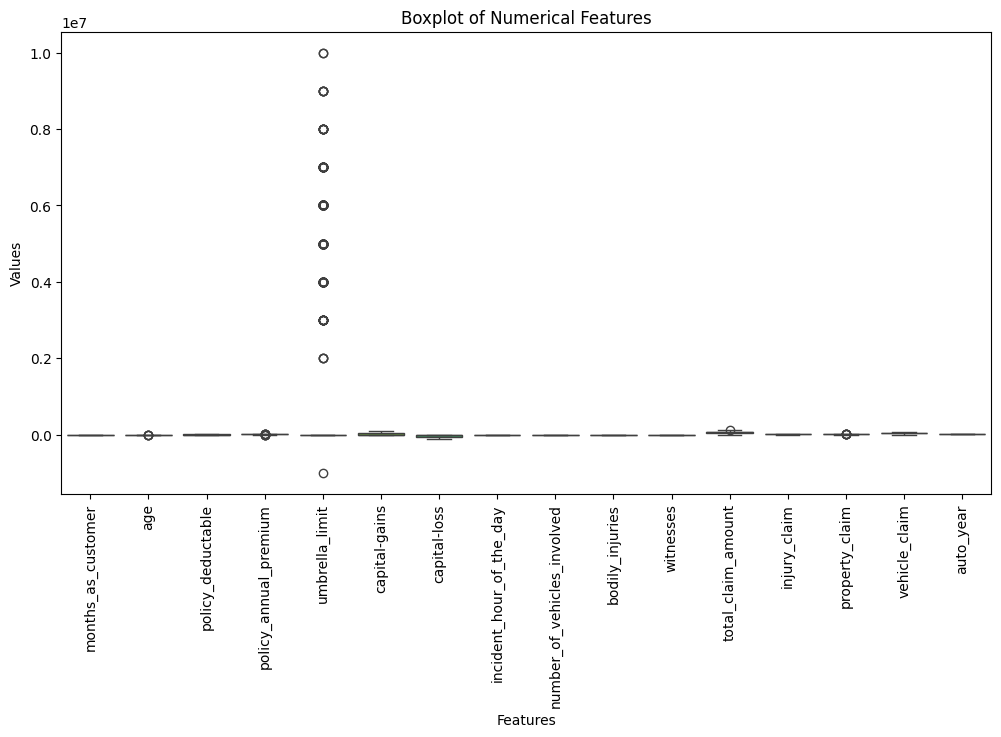

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[outlier_cols])

plt.title("Boxplot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=90)

plt.show()

In [ ]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers handled using IQR-based capping.")

Outliers handled using IQR-based capping.


### Target Encoding

The target variable `fraud_reported` contains two categories:

- N = Genuine
- Y = Fraud

These categories are converted into numerical labels for classification.

In [ ]:
df["fraud_reported"] = df["fraud_reported"].map({
    "N": 0,
    "Y": 1
})

print(df["fraud_reported"].value_counts())

fraud_reported
0    753
1    247
Name: count, dtype: int64


In [ ]:
selected_features = [
    "months_as_customer",
    "age",
    "policy_state",
    "policy_csl",
    "policy_deductable",
    "policy_annual_premium",
    "umbrella_limit",
    "insured_sex",
    "insured_education_level",
    "insured_occupation",
    "insured_relationship",
    "capital-gains",
    "capital-loss",
    "incident_type",
    "collision_type",
    "incident_severity",
    "authorities_contacted",
    "incident_state",
    "incident_hour_of_the_day",
    "number_of_vehicles_involved",
    "property_damage",
    "bodily_injuries",
    "witnesses",
    "police_report_available",
    "total_claim_amount",
    "injury_claim",
    "property_claim",
    "vehicle_claim",
    "auto_make",
    "auto_year"
]

In [ ]:
X = df[selected_features].copy()
y = df["fraud_reported"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 30)
Target: (1000,)


In [ ]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'property_damage', 'police_report_available', 'auto_make']

Numerical features:
['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']


In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Encoded data shape:", X_encoded.shape)

Encoded data shape: (1000, 77)


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the target variable and identify patterns and relationships among the features.

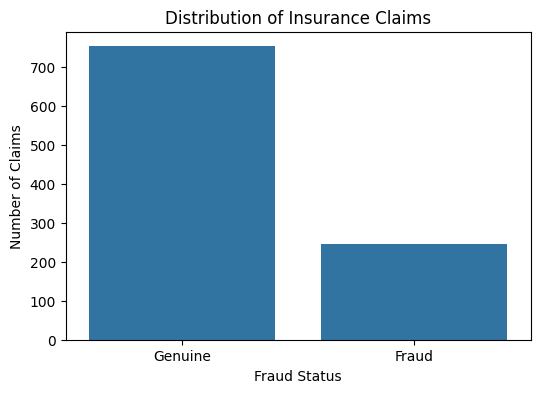

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x=df["fraud_reported"])

plt.title("Distribution of Insurance Claims")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Claims")

plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

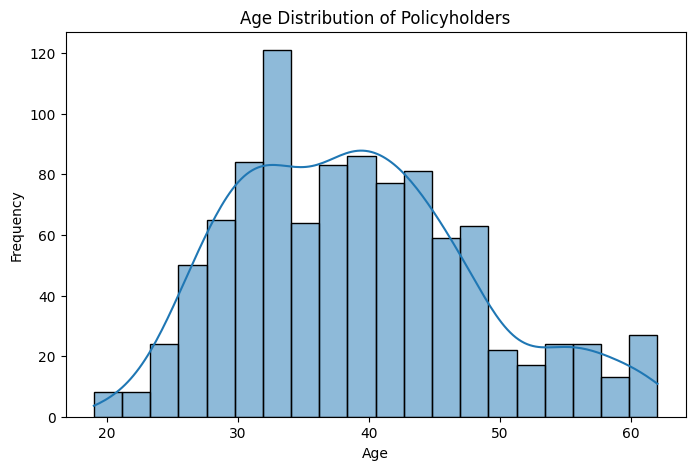

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Policyholders")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

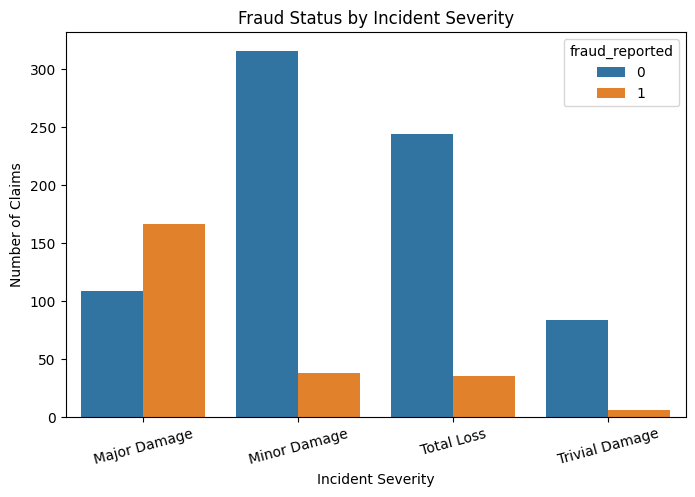

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="incident_severity",
    hue="fraud_reported"
)

plt.title("Fraud Status by Incident Severity")
plt.xlabel("Incident Severity")
plt.ylabel("Number of Claims")

plt.xticks(rotation=15)

plt.show()

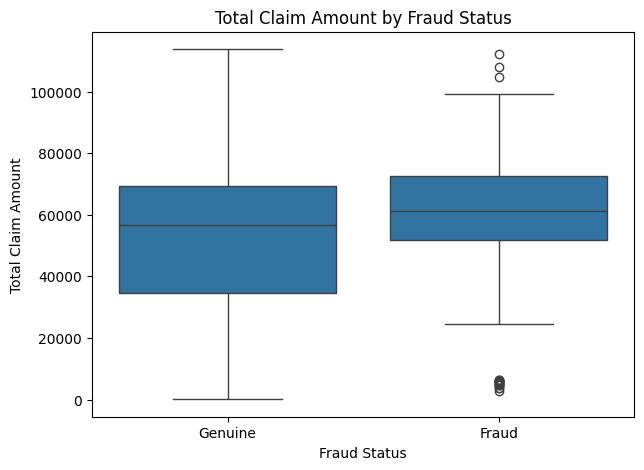

In [ ]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="fraud_reported",
    y="total_claim_amount"
)

plt.title("Total Claim Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Total Claim Amount")

plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

## 4. Feature Selection

Feature selection is performed to retain relevant variables and remove unnecessary or redundant information before model training.

The selected features represent policyholder characteristics, policy information, incident details and claim-related financial information.

In [ ]:
correlation_with_target = X_encoded.copy()

correlation_with_target["fraud_reported"] = y.values

correlations = correlation_with_target.corr()["fraud_reported"].drop(
    "fraud_reported"
).abs().sort_values(ascending=False)

print("Top 15 features related to fraud:")
print(correlations.head(15))

Top 15 features related to fraud:
incident_severity_Minor Damage            0.239716
incident_severity_Total Loss              0.171247
vehicle_claim                             0.170049
total_claim_amount                        0.163693
property_claim                            0.138192
authorities_contacted_Police              0.131655
incident_severity_Trivial Damage          0.131501
incident_type_Vehicle Theft               0.120916
incident_type_Parked Car                  0.106564
injury_claim                              0.090975
incident_type_Single Vehicle Collision    0.082534
incident_state_WV                         0.082123
authorities_contacted_Other               0.082010
insured_occupation_exec-managerial        0.080746
incident_state_OH                         0.066808
Name: fraud_reported, dtype: float64


In [ ]:
top_features = correlations.head(15).index.tolist()

X_selected = X_encoded[top_features]

print("Selected features:")
print(top_features)

print("\nSelected feature shape:", X_selected.shape)

Selected features:
['incident_severity_Minor Damage', 'incident_severity_Total Loss', 'vehicle_claim', 'total_claim_amount', 'property_claim', 'authorities_contacted_Police', 'incident_severity_Trivial Damage', 'incident_type_Vehicle Theft', 'incident_type_Parked Car', 'injury_claim', 'incident_type_Single Vehicle Collision', 'incident_state_WV', 'authorities_contacted_Other', 'insured_occupation_exec-managerial', 'incident_state_OH']

Selected feature shape: (1000, 15)


## 5. Train-Test Split

The selected dataset is divided into training and testing sets using an 80:20 ratio.

The training data is used to train the classification model, while the test data is used to evaluate its performance on unseen observations.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 15)
Testing set: (200, 15)


## 6. Classification Model – Logistic Regression

Logistic Regression is used to classify insurance claims as genuine or fraudulent.

Since the target variable has two classes, Logistic Regression is suitable for this binary classification problem.

Feature scaling is applied because Logistic Regression performs better when numerical features are on a similar scale.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 7. Model Prediction

The trained Logistic Regression model is used to predict whether the unseen insurance claims are genuine or fraudulent.

In [ ]:
# Predict the test data
y_pred = model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 1]


## 8. Model Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall and F1-Score.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.8
Precision: 0.5714
Recall   : 0.7347
F1-Score : 0.6429


### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Genuine", "Fraud"]
    )
)

              precision    recall  f1-score   support

     Genuine       0.91      0.82      0.86       151
       Fraud       0.57      0.73      0.64        49

    accuracy                           0.80       200
   macro avg       0.74      0.78      0.75       200
weighted avg       0.82      0.80      0.81       200



## 9. Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the Logistic Regression model.

- True Negative: Genuine claim correctly classified as genuine
- True Positive: Fraudulent claim correctly classified as fraud
- False Positive: Genuine claim incorrectly classified as fraud
- False Negative: Fraudulent claim incorrectly classified as genuine

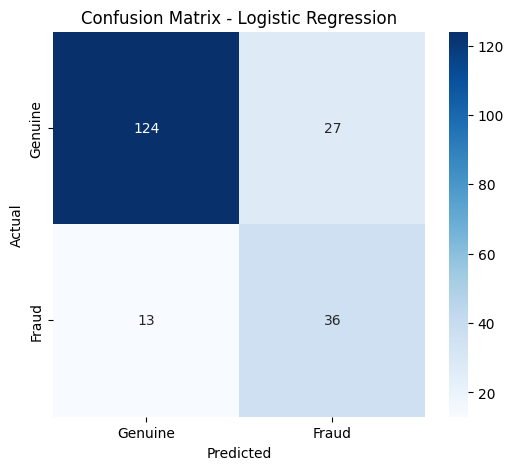

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## 10. Final Model Performance

In [ ]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

results

,Metric,Score
0,Accuracy,0.800000
1,Precision,0.571429
2,Recall,0.734694
3,F1-Score,0.642857


## 11. Result and Conclusion

Logistic Regression was used to classify insurance claims as genuine or fraudulent.

The dataset was cleaned by handling missing values, duplicate records and potential outliers. Categorical variables were converted into numerical form using one-hot encoding, and relevant features were selected for modelling.

The dataset was divided into training and testing sets using an 80:20 ratio. The numerical features were scaled using StandardScaler before training the Logistic Regression model.

The model was evaluated using Accuracy, Precision, Recall, F1-Score and a Confusion Matrix.

The results demonstrate that Logistic Regression can be used to identify potentially fraudulent insurance claims. In this application, recall is particularly important because a false negative represents a fraudulent claim incorrectly classified as genuine, which may result in financial loss for an insurance company.

Overall, machine learning can assist insurance companies in improving fraud detection and supporting financial risk management.